**PODDeepONet using DeepXDE module**

In [36]:
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch

Data loading

In [37]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5", 'r')
data_I = np.array(np.array(datastore["I"]))

data_c = np.array(np.array(datastore["c"]))
data_h = np.array(np.array(datastore["h"]))
t = np.linspace(0, 1, 601).reshape(601, 1)

Train-test split

In [38]:
train_label, test_label = train_test_split(range(len(data_I)), test_size=0.25, random_state=42)

data_i_train = data_I[train_label,:]
data_i_test = data_I[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

In [39]:
X_train = (data_i_train.astype(np.float32), t.astype(np.float32))
y_train_c = data_c_train.astype(np.float32)

In [40]:
X_test = (data_i_test.astype(np.float32), t.astype(np.float32))
y_test_c = data_c_test.astype(np.float32)

**Finding POD Basis**

In [41]:
def compute_pod(G, k=None, energy_threshold=0.99):
    """
    Compute the Proper Orthogonal Decomposition (POD) of a dataset.
    
    Parameters:
        G (numpy.ndarray): A matrix of shape (n_points, n_samples), 
                           where each column is a discretized function.
        energy_threshold (float): Fraction of total energy to capture (default: 99%).

    Returns:
        phi (numpy.ndarray): POD modes (basis functions) of shape (n_points, k).
        singular_values (numpy.ndarray): Singular values of G.
        energy_captured (list): Cumulative energy captured for each mode.
        k (int): Number of modes required to meet the energy threshold.
    """
    # Step 1: Perform Singular Value Decomposition (SVD)
    U, S, Vt = np.linalg.svd(G, full_matrices=False)
    # U: Left singular vectors (POD modes)
    # S: Singular values
    # Vt: Right singular vectors (transpose of eigenvectors of GG^T)
    
    # Step 2: Compute the total energy (sum of squared singular values)
    total_energy = np.sum(S**2)
    
    # Step 3: Compute the cumulative energy captured by each mode
    energy_captured = np.cumsum(S**2) / total_energy

    # Step 4: Determine the number of modes required to meet the energy threshold
    k = np.argmax(energy_captured >= energy_threshold) + 1  # First mode where energy exceeds threshold
    
    # Step 5: Return the POD modes and the number of modes
    phi = U[:, :k]  # Truncate U to get the first k modes
    return phi, S, energy_captured, k


In [42]:
# Compute POD
phi, singular_values, energy_captured, k = compute_pod(y_train_c.T, energy_threshold=0.999)

# Print results
print(f"Number of POD modes to capture 99% energy: {k}")
print(f"Singular values: {singular_values[:k]}")
print(f"Energy captured by each mode: {energy_captured[:k]}")
print(phi.shape)

Number of POD modes to capture 99% energy: 8
Singular values: [29059.234    7277.5806   2892.6194   1697.6475   1152.5188    841.9328
   689.4578    551.03906]
Energy captured by each mode: [0.9258206  0.98388803 0.99306166 0.99622136 0.99767774 0.9984549
 0.99897605 0.99930894]
(601, 8)


In [43]:
data_i_train_pod, singular_values_I_train, energy_captured_I_train, k_I_train = compute_pod(data_i_train, energy_threshold=0.999)

# Print results
print(f"Number of POD modes to capture 99% energy: {k_I_train}")
print(f"Singular values: {singular_values[:k_I_train]}")
print(f"Energy captured by each mode: {energy_captured[:k_I_train]}")
print(data_i_train_pod.shape)

Number of POD modes to capture 99% energy: 7
Singular values: [29059.234   7277.5806  2892.6194  1697.6475  1152.5188   841.9328
   689.4578]
Energy captured by each mode: [0.9258206  0.98388803 0.99306166 0.99622136 0.99767774 0.9984549
 0.99897605]
(81540, 7)


In [44]:
data_i_test_pod, singular_values_I_test, energy_captured_test, k_I_test = compute_pod(data_i_test, energy_threshold=0.999)

# Print results
print(f"Number of POD modes to capture 99% energy: {k_I_test}")
print(f"Singular values: {singular_values[:k_I_test]}")
print(f"Energy captured by each mode: {energy_captured[:k_I_test]}")
print(data_i_test_pod.shape)

Number of POD modes to capture 99% energy: 7
Singular values: [29059.234   7277.5806  2892.6194  1697.6475  1152.5188   841.9328
   689.4578]
Energy captured by each mode: [0.9258206  0.98388803 0.99306166 0.99622136 0.99767774 0.9984549
 0.99897605]
(27180, 7)


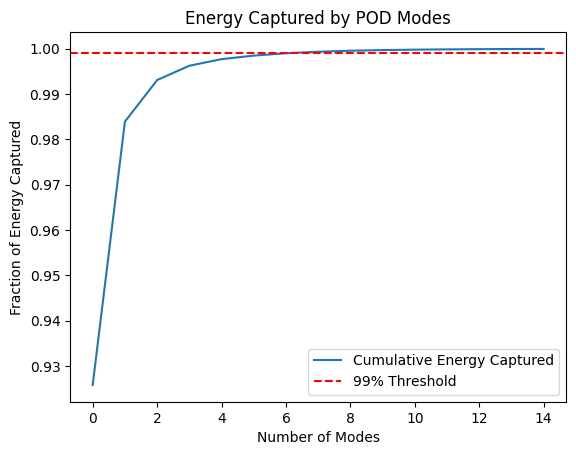

In [45]:
# Plot the cumulative energy
plt.plot(energy_captured[:15], label="Cumulative Energy Captured")
plt.axhline(0.999, color="red", linestyle="--", label="99% Threshold")
plt.xlabel("Number of Modes")
plt.ylabel("Fraction of Energy Captured")
plt.title("Energy Captured by POD Modes")
plt.legend()
plt.show()


In [46]:
X_train = (data_i_train_pod.astype(np.float32), t.astype(np.float32))
X_test = (data_i_test_pod.astype(np.float32), t.astype(np.float32))


**Making the data compatible with deepxde.nn.pytorch.deeponet.PODDeepONet**

In [47]:
data_c = dde.data.TripleCartesianProd(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)

**Defining the PODDeepONet model**

In [48]:
m = 601
net = dde.nn.PODDeepONet(
    pod_basis = phi,
    layer_sizes_branch = [k_I_train, 300, 300, 300, k],
    activation = "relu",
    kernel_initializer = "Glorot normal",
    # layer_sizes_trunk = [dim_x, 200, 200, 8],
)

**Counting the number of learnable parameters in the model**

In [49]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [k_I_train, 300, 300, 300, k]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 185408


**Training the model**

In [50]:
model_c = dde.Model(data_c, net)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_c.compile("adam", lr=0.001, metrics=["l2 relative error"])
# print(model_c.predict((data_i_test[0].reshape(1, -1), t)).shape)
losshistory_c, train_state_c = model_c.train(iterations=2000, display_every=100)

Compiling model...
'compile' took 0.000212 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.86e+01]    [1.87e+01]    [1.00e+00]    
100       [6.55e+00]    [6.54e+00]    [5.92e-01]    
200       [6.36e+00]    [6.33e+00]    [5.82e-01]    
300       [5.92e+00]    [5.89e+00]    [5.62e-01]    
400       [3.52e+00]    [5.32e+00]    [5.34e-01]    
500       [2.58e+00]    [6.22e+00]    [5.77e-01]    
600       [2.22e+00]    [6.09e+00]    [5.71e-01]    
700       [1.86e+00]    [5.89e+00]    [5.61e-01]    
800       [1.68e+00]    [5.67e+00]    [5.51e-01]    
900       [1.46e+00]    [5.90e+00]    [5.62e-01]    
1000      [1.30e+00]    [6.29e+00]    [5.80e-01]    
1100      [1.19e+00]    [6.74e+00]    [6.01e-01]    
1200      [1.10e+00]    [7.30e+00]    [6.25e-01]    
1300      [9.93e-01]    [7.94e+00]    [6.52e-01]    
1400      [8.95e-01]    [8.59e+00]    [6.78e-01]    
1500      [7.93e-01]    [9.37e+00]    [7.08e-01]    
1600      [6.96e-01]    [1.03e+01]

In [44]:
X_train = (data_i_train.astype(np.float32), t.astype(np.float32))
y_train_h = data_h_train.astype(np.float32)

In [45]:
X_test = (data_i_test.astype(np.float32), t.astype(np.float32))
y_test_h = data_h_test.astype(np.float32)

In [46]:
# Compute POD
phi_h, singular_values_h, energy_captured_h, k_h = compute_pod(y_train_h.T, energy_threshold=0.999)

# Print results
print(f"Number of POD modes to capture 99% energy: {k_h}")
print(f"Singular values: {singular_values_h[:k]}")
print(f"Energy captured by each mode: {energy_captured_h[:k]}")
print(phi_h.shape)

Number of POD modes to capture 99% energy: 5
Singular values: [2525.453     587.49915   352.32092   165.01639    92.14413    53.856476
   34.80667    23.001192]
Energy captured by each mode: [0.92592126 0.97602963 0.9940504  0.9980036  0.9992362  0.99965733
 0.99983317 0.99991   ]
(601, 5)


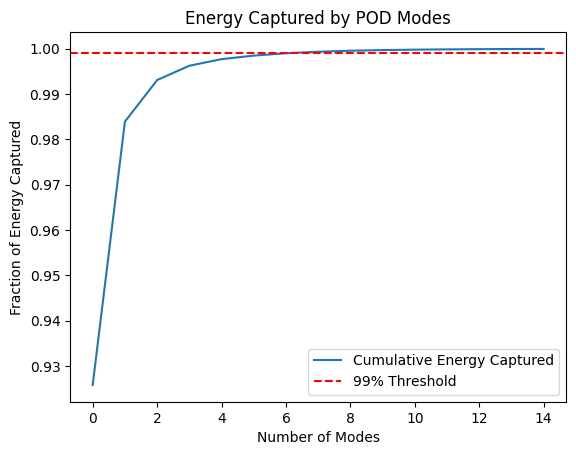

In [47]:
# Plot the cumulative energy
plt.plot(energy_captured[:15], label="Cumulative Energy Captured")
plt.axhline(0.999, color="red", linestyle="--", label="99% Threshold")
plt.xlabel("Number of Modes")
plt.ylabel("Fraction of Energy Captured")
plt.title("Energy Captured by POD Modes")
plt.legend()
plt.show()


In [48]:
data_h = dde.data.TripleCartesianProd(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)

In [49]:
m = 601
net_h = dde.nn.PODDeepONet(
    pod_basis = phi_h,
    layer_sizes_branch = [m, 200, 200, 200, k_h],
    activation = "relu",
    kernel_initializer = "Glorot normal",
)

In [50]:
model_h = dde.Model(data_h, net_h)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_h.compile("adam", lr=0.001)
# print(model_c.predict((data_i_test[0].reshape(1, -1), t)).shape)
losshistory_h, train_state_h = model_h.train(iterations=2000, display_every=100)

Compiling model...
'compile' took 0.000336 s

Training model...

Step      Train loss    Test loss     Test metric
0         [1.40e-01]    [1.39e-01]    []  
100       [1.65e-02]    [1.64e-02]    []  
200       [1.03e-02]    [1.04e-02]    []  
300       [7.50e-03]    [7.61e-03]    []  
400       [6.24e-03]    [6.38e-03]    []  
500       [5.53e-03]    [5.65e-03]    []  
600       [5.12e-03]    [5.24e-03]    []  
700       [4.83e-03]    [4.96e-03]    []  
800       [4.66e-03]    [4.81e-03]    []  
900       [4.38e-03]    [4.53e-03]    []  
1000      [4.24e-03]    [4.36e-03]    []  
1100      [4.19e-03]    [4.31e-03]    []  
1200      [4.01e-03]    [4.13e-03]    []  
1300      [3.99e-03]    [4.09e-03]    []  
1400      [3.85e-03]    [4.00e-03]    []  
1500      [3.70e-03]    [3.83e-03]    []  
1600      [3.68e-03]    [3.85e-03]    []  
1700      [3.98e-03]    [4.04e-03]    []  
1800      [3.48e-03]    [3.62e-03]    []  
1900      [3.52e-03]    [3.63e-03]    []  
2000      [3.53e-03]    [

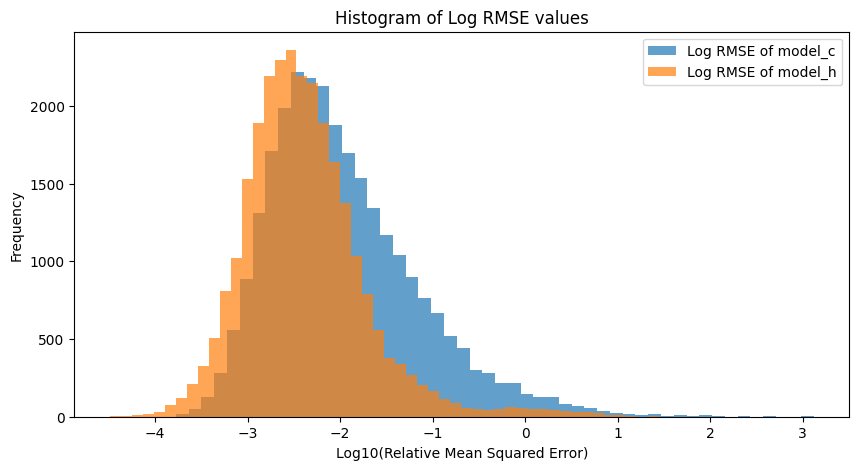

RMSE at c = 2: Mean = 0.09534689784049988, Std = 0.31243714690208435
RMSE at c = 3: Mean = 0.187160924077034, Std = 0.5471541881561279
RMSE at c = 4: Mean = 0.29730111360549927, Std = 0.8703595399856567


In [54]:
# Use trained model to make predictions
predictions_c = model_c.predict((data_i_test, t))  # Ensure model_c is defined
predictions_h = model_h.predict((data_i_test, t))  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c = np.mean((predictions_c - data_c_test) ** 2 / (data_c_test ** 2 + 1e-8), axis=1)  # Averaging across time points
rmse_h = np.mean((predictions_h - data_h_test) ** 2 / (data_h_test ** 2 + 1e-8), axis=1)  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points = [2, 3, 4]
errors_at_special_points = {str(point): [] for point in special_points}

for i in range(data_c_test.shape[0]):
    for point in special_points:
        if np.max(data_c_test[i])>=point:
            index = np.argmin(np.abs(data_c_test[i]-point))
            errors_at_special_points[str(point)].append(np.abs((predictions_c[i, index] - data_c_test[i, index])**2))

# Print analysis for special points
for point, errors in errors_at_special_points.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")


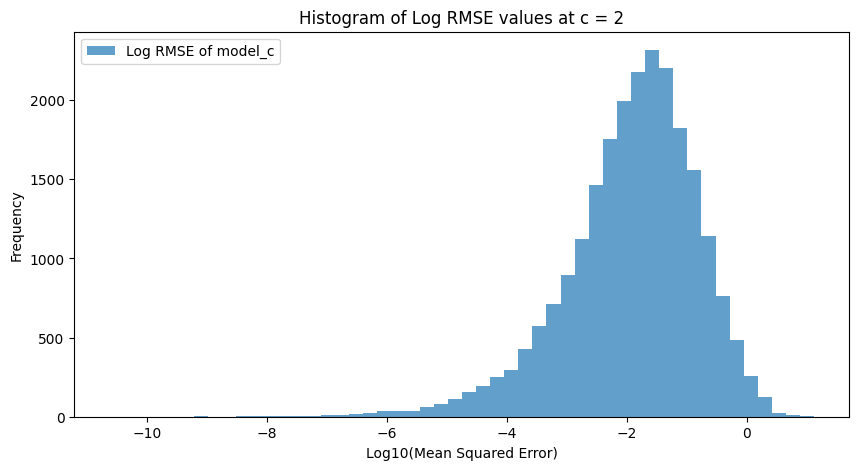

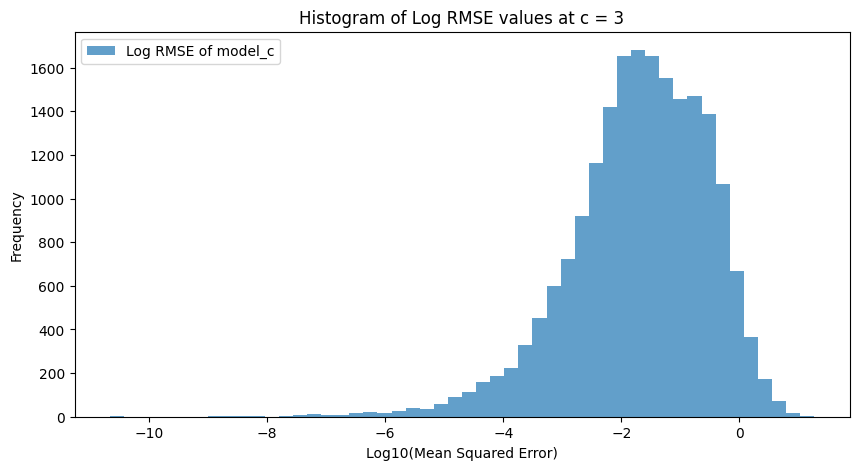

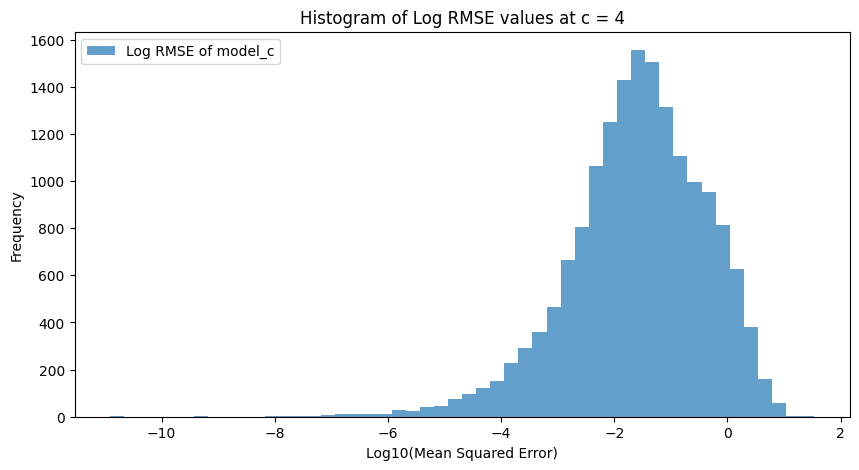

In [55]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["2"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 2')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["3"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 3')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["4"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 4')
plt.legend()
plt.show()

In [57]:
def find_sharpest_decline_point(data, mesh=np.linspace(0, 1, 601)):
    """
    Identifies the point where the second derivative is smallest for each function in the input matrix.
    
    Parameters:
        data (numpy.ndarray): A matrix of shape [n, 601] where each row represents a discretized function.
        mesh (numpy.ndarray): The mesh points corresponding to the function values (default: linspace(0, 1, 601)).
    
    Returns:
        numpy.ndarray: An array of shape [n] containing the mesh points where the second derivative is minimum.
    """
    h = mesh[1] - mesh[0]  # Step size
    n = data.shape[0]

    # Compute second derivative using finite difference approximation
    second_derivative = (data[:, :-2] + data[:, 2:] - 2 * data[:, 1:-1]) / (h ** 2)

    # Find the index of the minimum second derivative for each row
    min_indices = np.argmin(second_derivative, axis=1)

    # Map indices to corresponding mesh points
    min_points = mesh[min_indices + 1]  # +1 because second_derivative skips first and last points

    return min_points, min_indices

In [58]:
sharpest_points, sharpest_indices = find_sharpest_decline_point(data_c_test)

errors_at_sharpest_points = []

for i in range(data_c_test.shape[0]):
    errors_at_sharpest_points.append(np.abs((predictions_c[i, sharpest_indices[i]] - data_c_test[i, sharpest_indices[i]])**2))


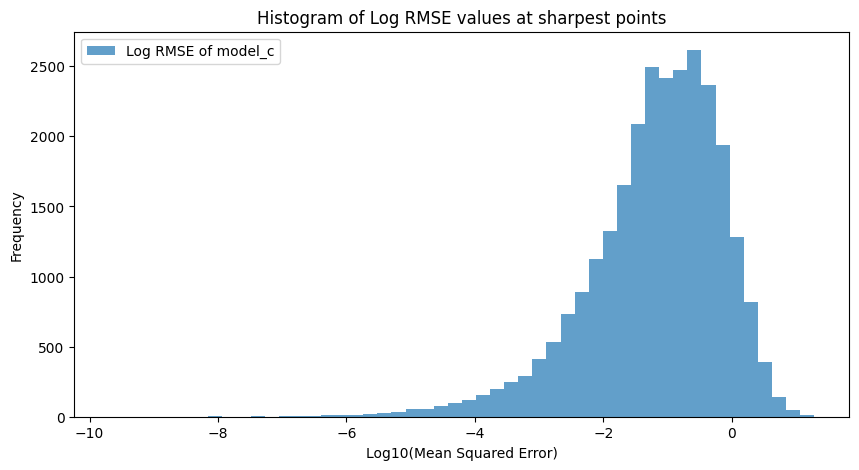

In [59]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_sharpest_points]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at sharpest points')
plt.legend()
plt.show()

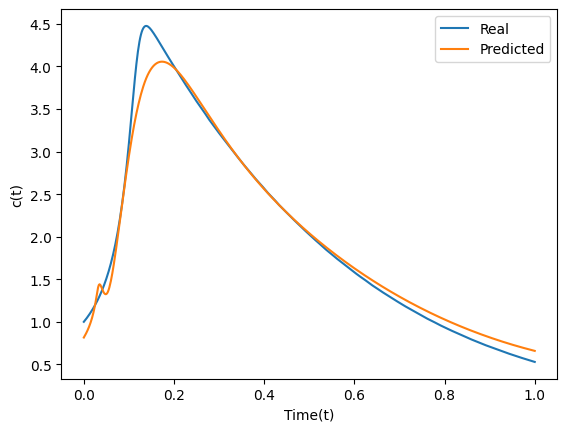

In [60]:
n = np.random.randint(0, len(data_h_test))
pred_c = model_c.predict((data_i_test[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

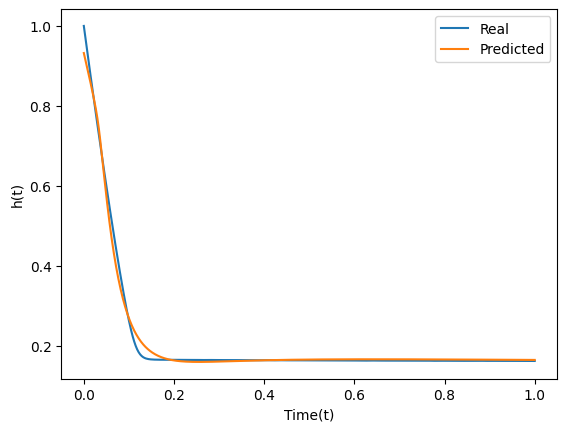

In [61]:
pred_h = model_h.predict((data_i_test[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

In [62]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_poddeeponet"
model_c.save(path)

'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_poddeeponet-2000.pt'

In [63]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_poddeeponet"
model_h.save(path)

'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_poddeeponet-2000.pt'